In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/Global_Superstore.csv')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,2/5/2014,2/7/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/5/2014,11/6/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [ ]:
print("Shape of the dataframe:")
print(df.shape)
print("\nDescriptive statistics of the dataframe:")
print(df.describe())

Shape of the dataframe:
(1000, 24)

Descriptive statistics of the dataframe:
             Row ID   Postal Code        Sales    Quantity     Discount  \
count   1000.000000    194.000000  1000.000000  1000.00000  1000.000000   
mean   25079.328000  53966.170103  1710.971470     5.55800     0.092840   
std    12897.726632  33734.306466  1259.239238     2.71846     0.148666   
min       58.000000   2920.000000     1.910000     1.00000     0.000000   
25%    15118.750000  19134.000000   826.907500     4.00000     0.000000   
50%    25084.500000  60564.000000  1585.115000     5.00000     0.000000   
75%    34524.000000  88187.500000  2477.812500     7.00000     0.150000   
max    51284.000000  98198.000000  9892.740000    14.00000     0.800000   

            Profit  Shipping Cost  
count  1000.000000    1000.000000  
mean    288.920440     272.384897  
std     574.504782     176.160716  
min   -3059.820000       1.070000  
25%      10.037500     209.827500  
50%     190.685000     258.8975

## **Data Cleaning & Pre-Processing**


Check for missing values
   Handle any missing or inconsistent data
   Convert data types if necessary (e.g., dates to datetime objects)

In [ ]:
print("Missing values before handling:")
print(df.isnull().sum())

# Convert date columns to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("\nData types after converting date columns:")
print(df.info())

Missing values before handling:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

Data types after converting date columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1000 non-null   int64         
 1   Order ID        1000 non-null   object        
 2   Order Date      1000 non-null   datetime64[ns]
 3   Ship Date    

Basic Analysis

   Calculate total sales and profit
   Identify top-selling products
   Analyze sales by region
   Examine the relationship between sales and profit

In [ ]:
# Calculate total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"Total Sales: {total_sales:.2f}")
print(f"Total Profit: {total_profit:.2f}")

# Identify top-selling products
top_selling_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Selling Products:")
print(top_selling_products)

# Analyze sales by region
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Region:")
print(sales_by_region)

# Examine the relationship between sales and profit (using correlation)
sales_profit_correlation = df['Sales'].corr(df['Profit'])
print(f"\nCorrelation between Sales and Profit: {sales_profit_correlation:.2f}")

Total Sales: 1710971.47
Total Profit: 288920.44

Top 10 Selling Products:
Product Name
Motorola Smart Phone, Full Size                             48542.52
Apple Smart Phone, Full Size                                42303.44
Cisco Smart Phone, Full Size                                41325.20
Nokia Smart Phone, Full Size                                27661.97
Samsung Smart Phone, Cordless                               25438.59
Hoover Stove, Red                                           23477.81
Motorola Smart Phone, with Caller ID                        23239.44
Harbour Creations Executive Leather Armchair, Adjustable    22145.80
Cisco Smart Phone, with Caller ID                           22047.89
Cisco Smart Phone, Cordless                                 21954.87
Name: Sales, dtype: float64

Sales by Region:
Region
Western Europe       259576.28
Oceania              220809.08
Southern Asia        205466.26
Eastern Asia         193590.60
Southeastern Asia    147337.60
Central America

Data Visualization

   Create a bar chart of sales by product category
   Plot a line graph of monthly sales over time
   Generate a scatter plot of sales vs. profit
   Produce a heatmap of sales by region and product category

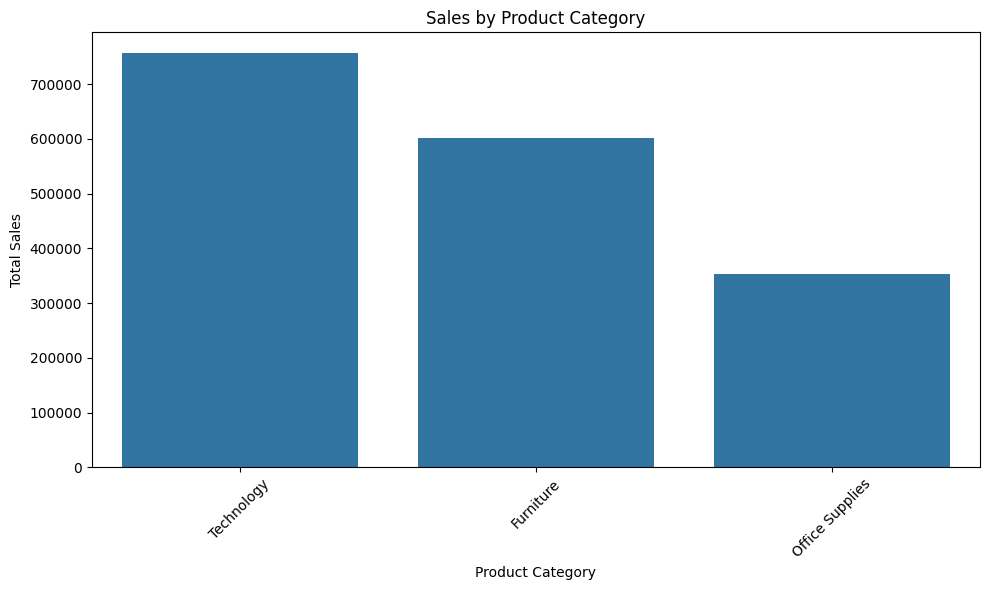

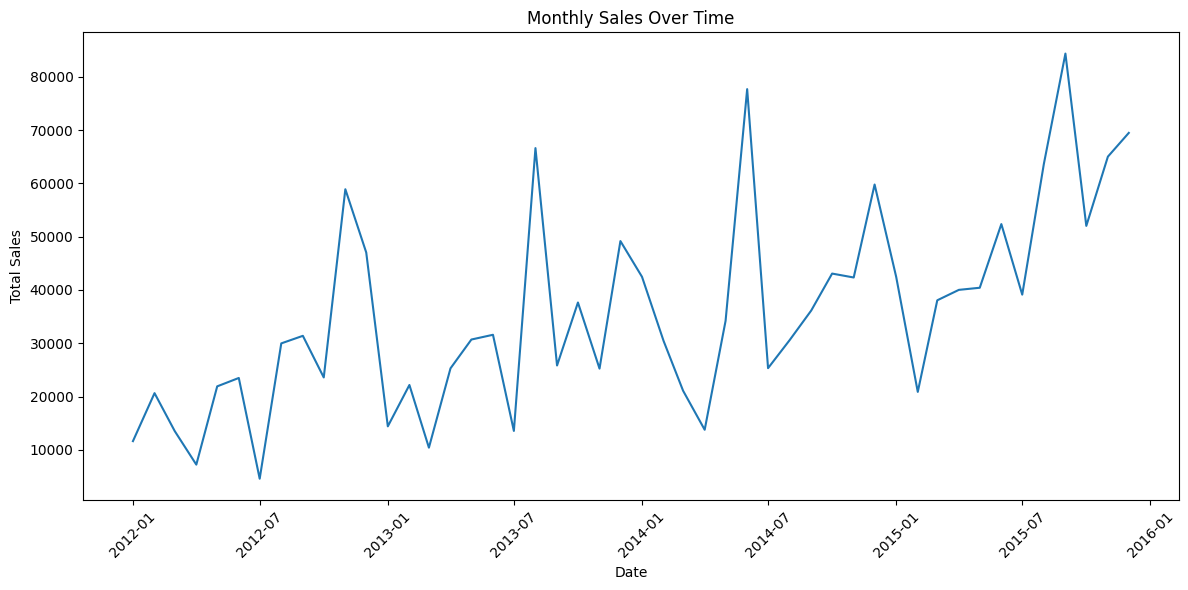

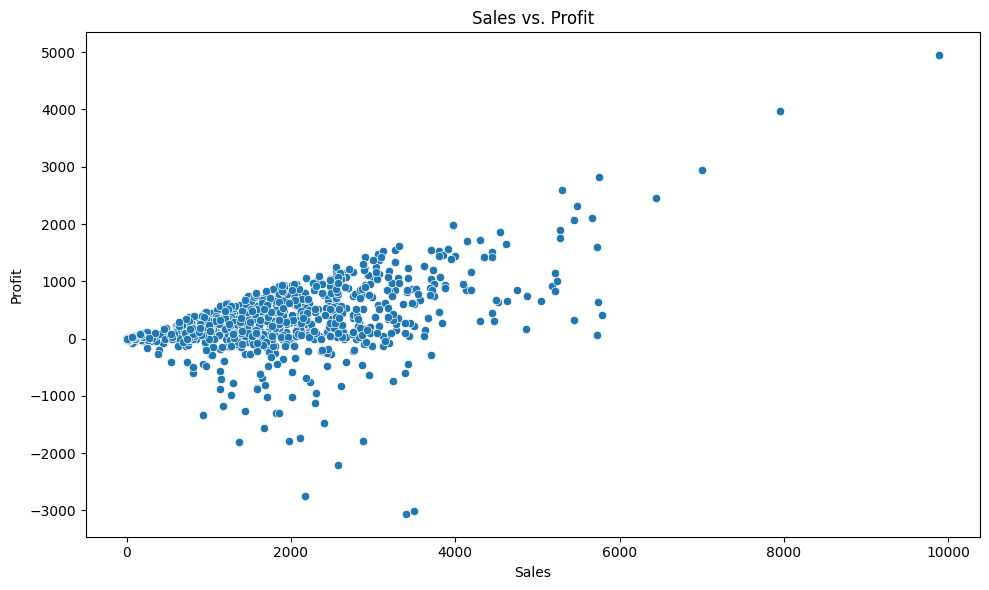

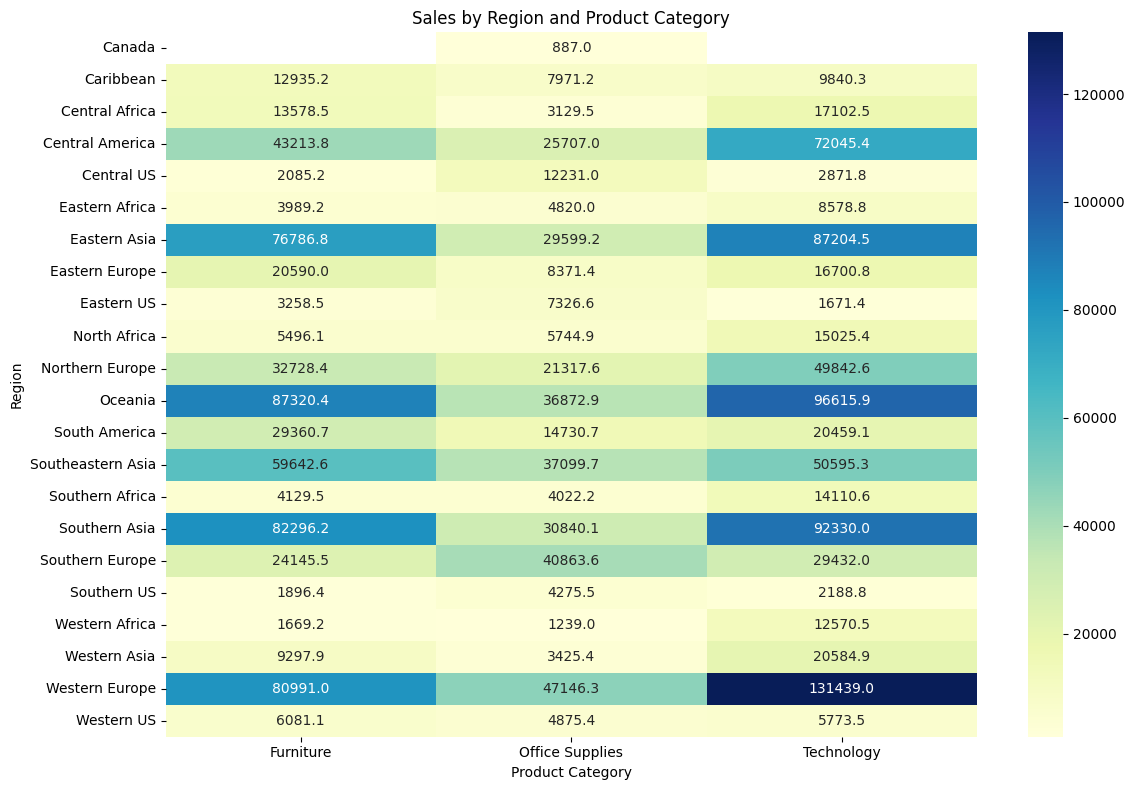

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar chart of sales by product category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)
plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot a line graph of monthly sales over time
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Order Month')['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title('Monthly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Generate a scatter plot of sales vs. profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs. Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

# Produce a heatmap of sales by region and product category
sales_heatmap_data = df.groupby(['Region', 'Category'])['Sales'].sum().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(sales_heatmap_data, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Sales by Region and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

Derive Insights

   Based on your analysis and visualizations, list 3-5 key insights about GlobalMart's sales performance

In [ ]:
# Based on the analysis and visualizations, here are some key insights about GlobalMart's sales performance:
print("Key Insights about GlobalMart's Sales Performance:")
print("- Technology and Furniture are the top-selling product categories, significantly contributing to total sales.")
print("- Sales show a clear upward trend over time, with notable peaks towards the end of each year.")
print("- There is a positive correlation between Sales and Profit (0.53), suggesting that higher sales generally lead to higher profits, although there are instances of sales with negative profit.")
print("- Western Europe, Oceania, and Southern Asia are the top-performing regions in terms of sales.")
print("- The heatmap reveals that 'Technology' products contribute significantly to sales across most regions, while the performance of 'Furniture' and 'Office Supplies' varies more by region.")

Key Insights about GlobalMart's Sales Performance:
- Technology and Furniture are the top-selling product categories, significantly contributing to total sales.
- Sales show a clear upward trend over time, with notable peaks towards the end of each year.
- There is a positive correlation between Sales and Profit (0.53), suggesting that higher sales generally lead to higher profits, although there are instances of sales with negative profit.
- Western Europe, Oceania, and Southern Asia are the top-performing regions in terms of sales.
- The heatmap reveals that 'Technology' products contribute significantly to sales across most regions, while the performance of 'Furniture' and 'Office Supplies' varies more by region.


Bonus Challenge

   Perform a simple time series analysis to identify any sales trends or seasonality

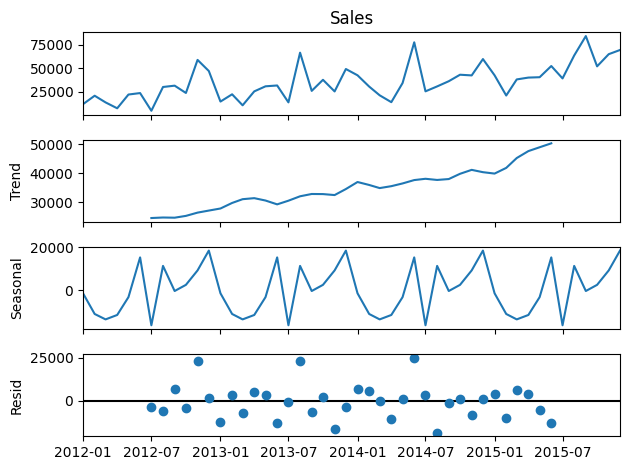

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform seasonal decomposition
decomposition = seasonal_decompose(monthly_sales, model='additive')

# Plot the decomposed components
fig = decomposition.plot()
plt.show()

Prepare a Summary

    Write a brief report (300-500 words) summarizing your findings and recommendations for GlobalMart

## GlobalMart Sales Performance Summary and Recommendations

Based on the analysis of the GlobalMart sales data, several key insights have been identified, along with recommendations for improving sales performance.

**Key Findings:**

1.  **Top-Performing Categories:** Technology and Furniture are the leading product categories in terms of total sales, contributing significantly to GlobalMart's revenue. Office Supplies, while still a substantial contributor, has lower sales compared to the other two categories.
2.  **Sales Trends and Seasonality:** The time series analysis revealed a clear upward trend in overall sales over the observed period. There is also a distinct seasonality, with sales peaking towards the end of each year, likely due to holiday shopping seasons.
3.  **Sales and Profit Relationship:** A positive correlation (0.53) exists between Sales and Profit, indicating that higher sales generally result in increased profits. However, the scatter plot shows instances of sales with negative profit, suggesting potential issues with pricing, costs, or discounts on certain products or in specific regions.
4.  **Regional Performance:** Western Europe, Oceania, and Southern Asia are the top-performing regions in terms of total sales. This indicates strong market presence and customer demand in these areas.
5.  **Category Performance by Region:** The heatmap highlights that Technology products consistently perform well across most regions. The performance of Furniture and Office Supplies varies more significantly by region, suggesting that regional preferences or market conditions may play a role.

**Recommendations:**

1.  **Capitalize on Top Categories:** Continue to focus on and invest in the Technology and Furniture categories, exploring opportunities to expand product offerings and marketing efforts in these areas.
2.  **Leverage Seasonal Peaks:** Develop targeted marketing campaigns and inventory management strategies to maximize sales during the observed year-end peaks. Consider similar, smaller campaigns during other periods of potential seasonality.
3.  **Investigate Low-Profit Sales:** Analyze the products and regions where sales are resulting in negative profit. This deeper dive can help identify root causes such as excessive discounts, high shipping costs, or unfavorable market conditions, allowing for corrective actions.
4.  **Expand in High-Performing Regions:** Explore opportunities for further expansion and market penetration in Western Europe, Oceania, and Southern Asia. This could involve increasing marketing spend, opening new distribution centers, or tailoring product offerings to regional preferences.
5.  **Regional Category Strategies:** Develop region-specific strategies for Furniture and Office Supplies based on the heatmap analysis. This might involve adjusting product mix, pricing, or marketing approaches to better suit the demand and competition in different regions.

By implementing these recommendations, GlobalMart can further optimize its sales strategies, improve profitability, and continue to grow its market presence globally.

Questions to Consider
Which product categories are the most profitable?
Are there any noticeable trends in sales over time?
How do sales and profits vary by region?
Is there a correlation between discount and profit?


Remember to document your code with comments and markdown cells to explain your thought process and findings.

In [ ]:
# Which product categories are the most profitable?
profit_by_category = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print("Profit by Product Category:")
print(profit_by_category)

# How do sales and profits vary by region? (Sales by region was already calculated)
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Region:")
print(profit_by_region)

# Is there a correlation between discount and profit?
discount_profit_correlation = df['Discount'].corr(df['Profit'])
print(f"\nCorrelation between Discount and Profit: {discount_profit_correlation:.2f}")

Profit by Product Category:
Category
Technology         145068.68
Furniture           82188.95
Office Supplies     61662.81
Name: Profit, dtype: float64

Profit by Region:
Region
Eastern Asia         37911.16
Southern Asia        37536.60
Oceania              33777.56
Western Europe       32783.40
Northern Europe      23552.73
Central America      21741.95
Southern Europe      20557.50
Eastern Europe       12228.45
Southeastern Asia    10561.80
Central Africa        9668.22
South America         7723.58
North Africa          7416.42
Central US            5676.02
Caribbean             5463.82
Western Asia          5262.35
Southern Africa       4876.32
Eastern Africa        4302.72
Eastern US            2544.89
Western US            2458.34
Southern US           1384.72
Western Africa        1278.17
Canada                 213.72
Name: Profit, dtype: float64

Correlation between Discount and Profit: -0.51
